/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)
berlin districts removed
Epoch 1 train loss: 0.6197, val loss: 0.7319 ✓ (new best)
Epoch 2 train loss: 0.5818, val loss: 0.6453 ✓ (new best)
Epoch 3 train loss: 0.5767, val loss: 0.6264 ✓ (new best)
Epoch 4 train loss: 0.5645, val loss: 0.5770 ✓ (new best)
Epoch 5 train loss: 0.5603, val loss: 0.5894 (patience: 1/20)
Epoch 6 train loss: 0.5583, val loss: 0.6134 (patience: 2/20)
Epoch 7 train loss: 0.5471, val loss: 0.5419 ✓ (new best)
Epoch 8 train loss: 0.5406, val loss: 0.5554 (patience: 1/20)
Epoch 9 train loss: 0.5347, val loss: 0.5366 ✓ (new best)
Epoch 10 train loss: 0.5305, val loss: 0.5440 (patience: 1/20)
Epoch 11 train loss: 0.5243, val loss: 0.5354 ✓ (new best)
Epoch 12 train loss: 0.5193, val loss: 0.5375 (patience: 1/20)
Epoch 13 train loss: 0.5139, val loss: 0.5420 (patience: 2/20)
Epoch 14 train loss: 0.5192, val loss: 0.5837 (patience: 3/20)
Epoch 15 train loss: 0.5097, va

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>],
       dtype=object))

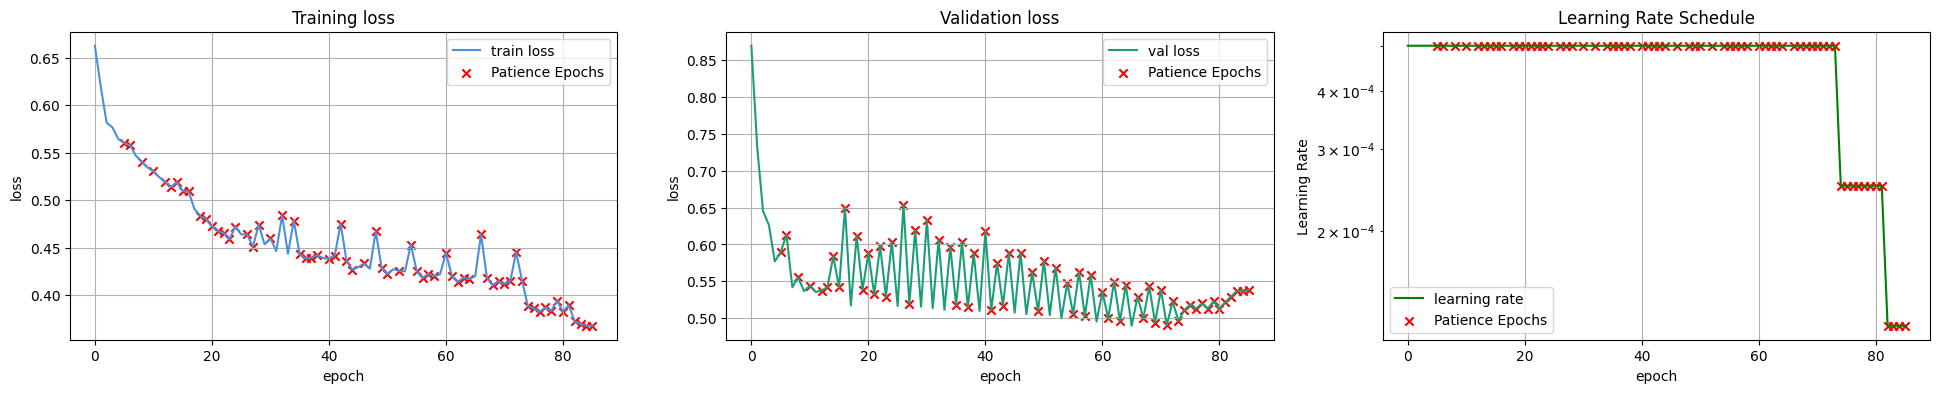

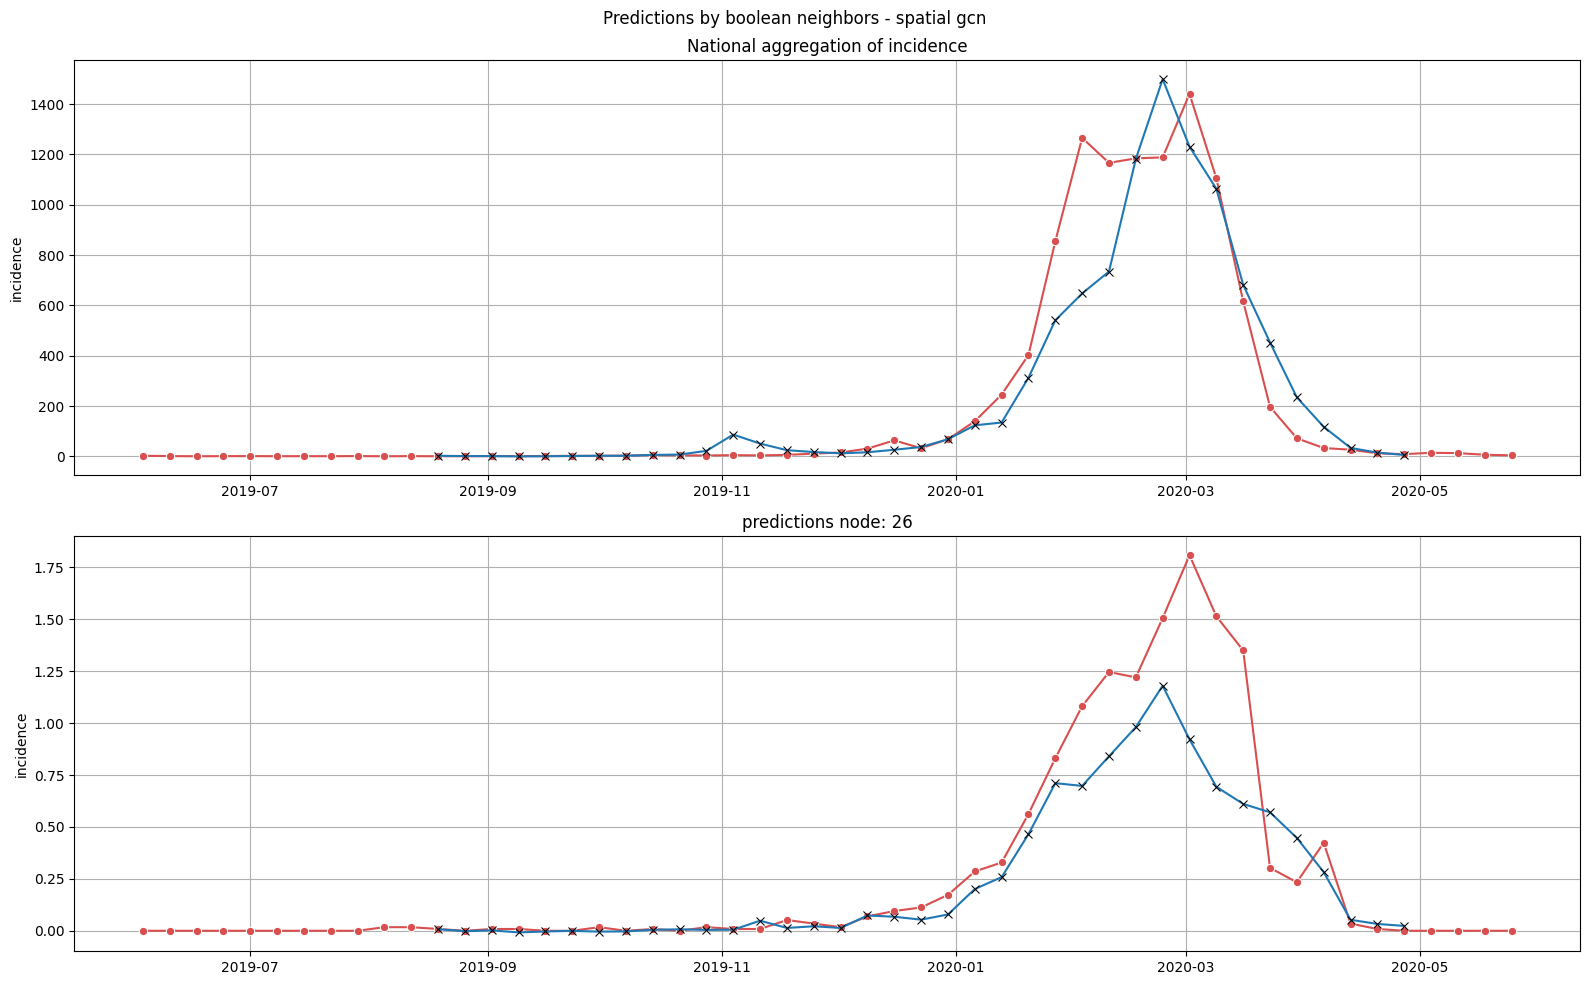

In [1]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env
from src.models.spatialgcn_baseline import SpatialGCNModel

disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 12
lags            = 1

graphtype       = 'boolean_neighbors_selfmean'
modelname       = 'boolean neighbors - spatial gcn'

# training hparams
n_epochs        = 100
lr              = 0.0005
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epidata_loader_bn = GNNDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_bn.add_time_features()
epidata_loader_bn.log_transform_target()
epidata_loader_bn.set_splits(split_trainval, split_valtest)
epidata_loader_bn.normalize()
epidata_loader_bn.add_lagged_features(lags = lags)
epidata_loader_bn.finalize()
epidata_loader_bn.retrieve_graph(graphtype)
epidata_loader_bn.construct_dataloaders()

spatial_bn = SpatialGCNModel(epidata_loader_bn, name = modelname)
spatial_bn.set_model_hparams()
spatial_bn.set_global_hparams(**global_hparams)
spatial_bn.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
spatial_bn.forecast('test')
spatial_bn.show_forecasts('test', 26)

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)
berlin districts removed
Epoch 1 train loss: 0.5976, val loss: 0.6711 ✓ (new best)
Epoch 2 train loss: 0.5650, val loss: 0.5604 ✓ (new best)
Epoch 3 train loss: 0.5554, val loss: 0.5837 (patience: 1/20)
Epoch 4 train loss: 0.5501, val loss: 0.5691 (patience: 2/20)
Epoch 5 train loss: 0.5471, val loss: 0.5531 ✓ (new best)
Epoch 6 train loss: 0.5377, val loss: 0.5316 ✓ (new best)
Epoch 7 train loss: 0.5316, val loss: 0.5329 (patience: 1/20)
Epoch 8 train loss: 0.5265, val loss: 0.5186 ✓ (new best)
Epoch 9 train loss: 0.5242, val loss: 0.5335 (patience: 1/20)
Epoch 10 train loss: 0.5234, val loss: 0.5928 (patience: 2/20)
Epoch 11 train loss: 0.5114, val loss: 0.4942 ✓ (new best)
Epoch 12 train loss: 0.5150, val loss: 0.5889 (patience: 1/20)
Epoch 13 train loss: 0.5135, val loss: 0.5608 (patience: 2/20)
Epoch 14 train loss: 0.5094, val loss: 0.5414 (patience: 3/20)
Epoch 15 train loss: 0.5022

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>],
       dtype=object))

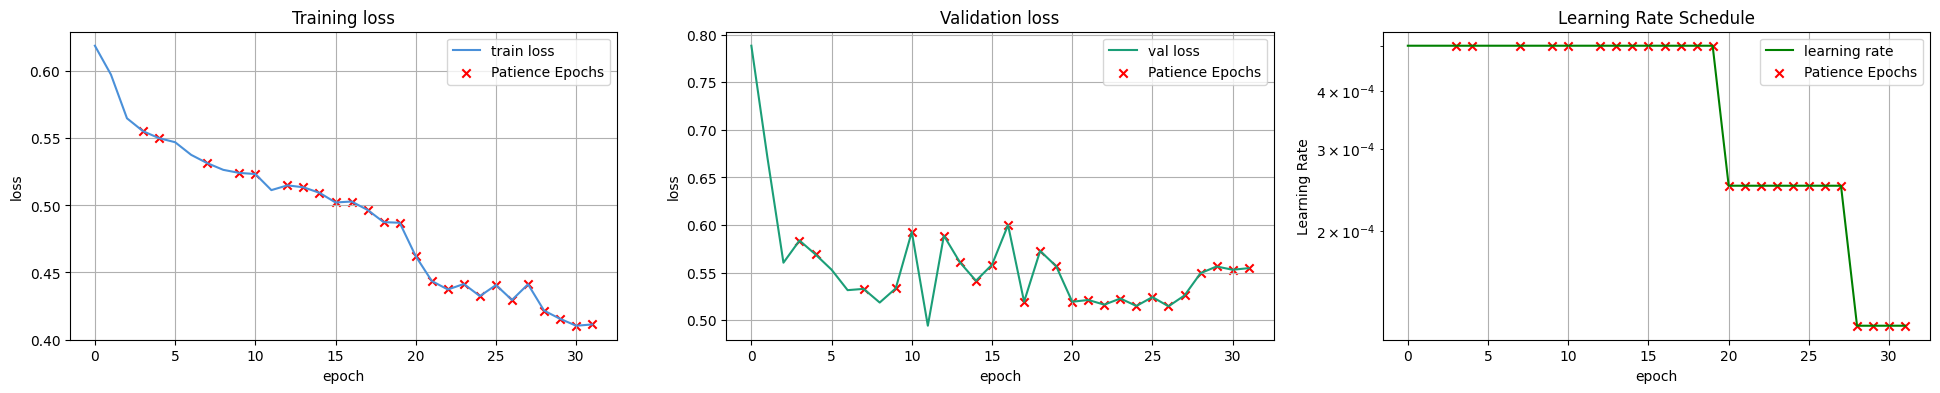

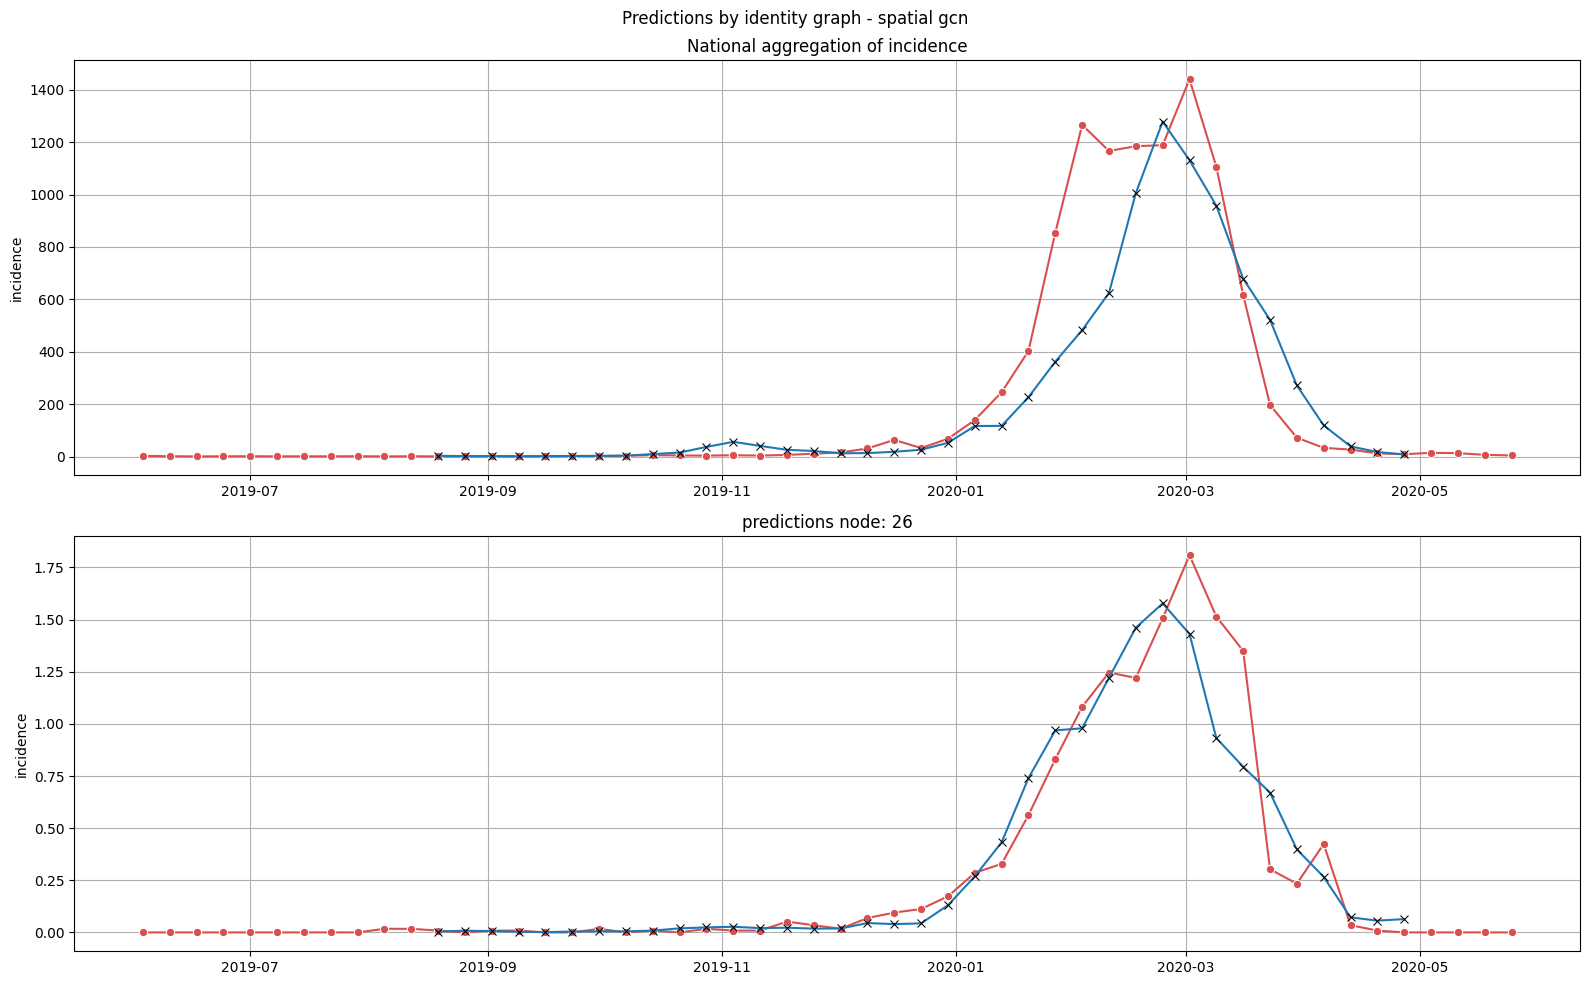

In [2]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env

disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 12
lags            = 1

graphtype       = 'identity_selfmean'
modelname       = 'identity graph - spatial gcn'

epidata_loader_id = GNNDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_id.add_time_features()
epidata_loader_id.log_transform_target()
epidata_loader_id.set_splits(split_trainval, split_valtest)
epidata_loader_id.normalize()
epidata_loader_id.add_lagged_features(lags = lags)
epidata_loader_id.finalize()
epidata_loader_id.retrieve_graph(graphtype)
epidata_loader_id.construct_dataloaders()

spatial_id = SpatialGCNModel(epidata_loader_id, name = modelname)
spatial_id.set_model_hparams()
spatial_id.set_global_hparams(**global_hparams)
spatial_id.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
spatial_id.forecast('test')
spatial_id.show_forecasts('test', 26)

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)
berlin districts removed
Epoch 1 train loss: 0.6686, val loss: 0.8946 ✓ (new best)
Epoch 2 train loss: 0.6274, val loss: 0.8204 ✓ (new best)
Epoch 3 train loss: 0.6135, val loss: 0.7631 ✓ (new best)
Epoch 4 train loss: 0.6023, val loss: 0.7444 ✓ (new best)
Epoch 5 train loss: 0.6040, val loss: 0.7985 (patience: 1/20)
Epoch 6 train loss: 0.5936, val loss: 0.7096 ✓ (new best)
Epoch 7 train loss: 0.5834, val loss: 0.7075 ✓ (new best)
Epoch 8 train loss: 0.5712, val loss: 0.6533 ✓ (new best)
Epoch 9 train loss: 0.5717, val loss: 0.6954 (patience: 1/20)
Epoch 10 train loss: 0.5615, val loss: 0.6326 ✓ (new best)
Epoch 11 train loss: 0.5607, val loss: 0.6820 (patience: 1/20)
Epoch 12 train loss: 0.5521, val loss: 0.6200 ✓ (new best)
Epoch 13 train loss: 0.5488, val loss: 0.6589 (patience: 1/20)
Epoch 14 train loss: 0.5433, val loss: 0.6390 (patience: 2/20)
Epoch 15 train loss: 0.5316, val loss: 

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>],
       dtype=object))

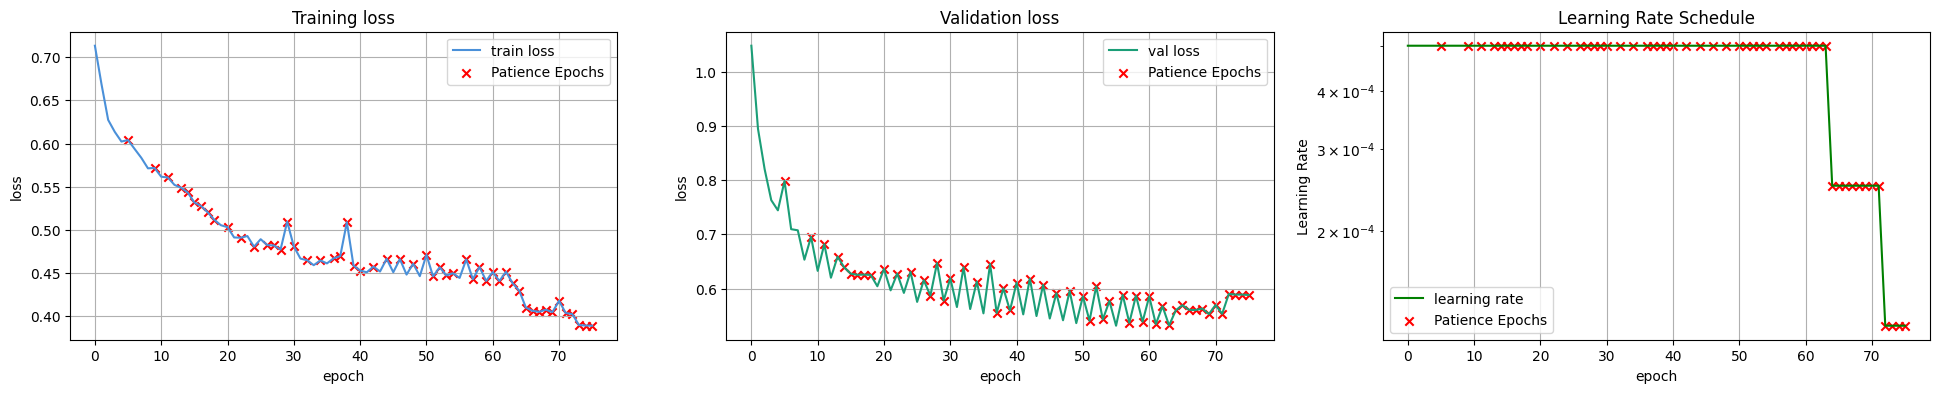

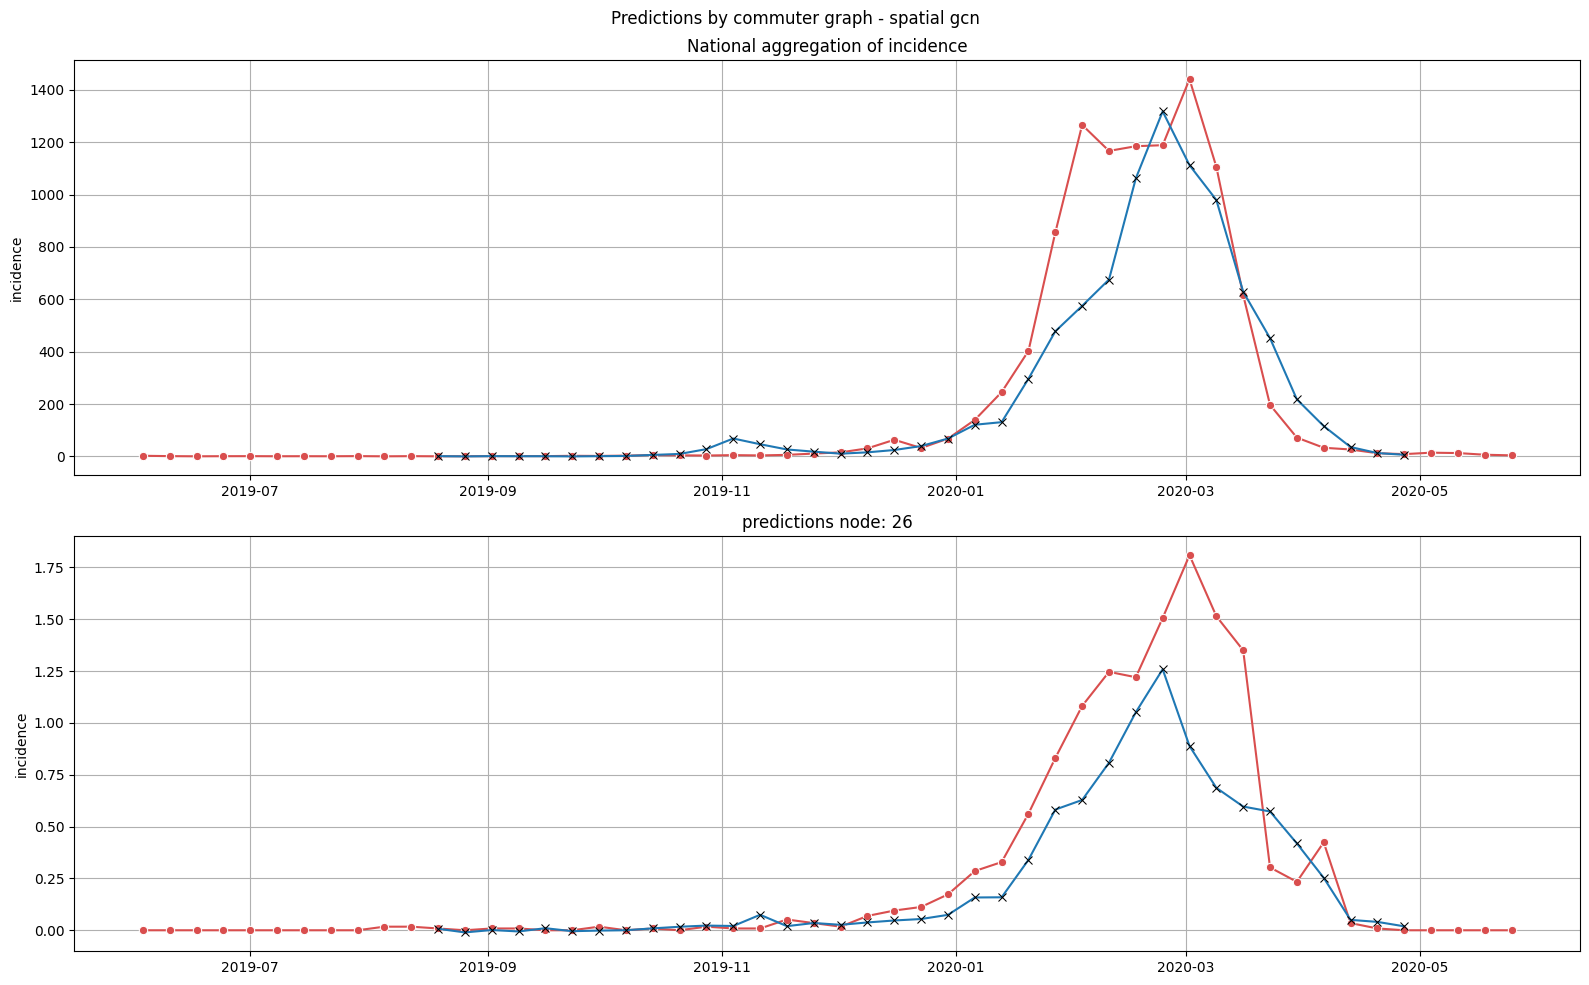

In [15]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env

disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 12
lags            = 1

# training hparams
n_epochs        = 200
lr              = 0.0005
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

graphtype       = 'commuter_t1500_selfmean_rowwise'
modelname       = 'commuter graph - spatial gcn'

epidata_loader_commuter = GNNDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_commuter.add_time_features()
epidata_loader_commuter.log_transform_target()
epidata_loader_commuter.set_splits(split_trainval, split_valtest)
epidata_loader_commuter.normalize()
epidata_loader_commuter.add_lagged_features(lags = lags)
epidata_loader_commuter.finalize()
epidata_loader_commuter.retrieve_graph(graphtype)
epidata_loader_commuter.construct_dataloaders()

spatial_commuter = SpatialGCNModel(epidata_loader_commuter, name = modelname)
spatial_commuter.set_model_hparams()
spatial_commuter.set_global_hparams(**global_hparams)
spatial_commuter.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
spatial_commuter.forecast('test')
spatial_commuter.show_forecasts('test', 26)